<a href="https://colab.research.google.com/github/raphaelassoun23/Projet-Python/blob/main/notebooks/MonteCarloCrypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import sys
from pathlib import Path

SRC_PATH = Path("..") / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from fetch import fetch_dataset

In [4]:
from config import TICKERS, ROLLING_WINDOW_DAYS, EVENT_DATE, EVENT_WINDOW_DAYS, EVENT_ROLLING_DAYS
from fetch import fetch_dataset
from process import build_final_dataset
from visualize import (
    print_correlations, plot_btc_sp500, plot_btc_nasdaq, plot_sp500_nasdaq, plot_event_window, 
    plot_btc_and_us10y, plot_rolling_corr, plot_scatter_returns, plot_event_study_rate_shocks, 
    plot_btc_vs_slope, plot_asset_and_us10y,plot_rolling_corr_generic,plot_event_study_rate_shocks_multi
)

ImportError: cannot import name 'plot_asset_and_us10y' from 'visualize' (c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\visualize.py)

Les valeurs manquantes présentes dans le dataset proviennent uniquement des transformations réalisées (retours, volatilités, moyennes mobiles). Ces NaN correspondent aux premières observations où les fenêtres de calcul ne sont pas encore complètes.
Ils ne représentent donc pas de véritables trous dans les données.
Leur suppression est justifiée, car elle ne retire qu’un très faible nombre d’observations et évite d’introduire un biais par une imputation artificielle
(par la moyenne,par la médiane ou par régression)

c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticke

                     BTC_return_daily  SP500_return_daily  NASDAQ_return_daily
BTC_return_daily             1.000000            0.294990             0.311703
SP500_return_daily           0.294990            1.000000             0.950932
NASDAQ_return_daily          0.311703            0.950932             1.000000

                     ETH_return_daily  SP500_return_daily  NASDAQ_return_daily
ETH_return_daily             1.000000            0.322073             0.336416
SP500_return_daily           0.322073            1.000000             0.950932
NASDAQ_return_daily          0.336416            0.950932             1.000000

                  ETH_return_daily  BTC_return_daily
ETH_return_daily          1.000000          0.812507
BTC_return_daily          0.812507          1.000000



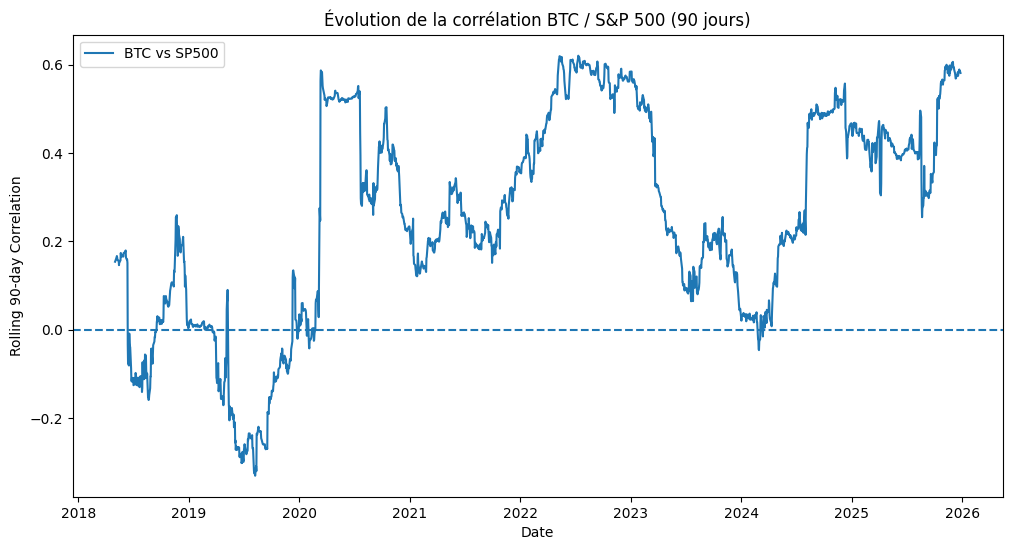

In [ ]:
df = fetch_dataset(TICKERS)
df_final = build_final_dataset(df)

print_correlations(df_final)
plot_btc_sp500(df_final)

Les premières observations sur les rendements journaliers montrent que le Bitcoin présente une corrélation faible à modérée avec le S&P 500 (≈0,29) et le NASDAQ (≈0,31). En comparaison, le S&P 500 et le NASDAQ sont fortement corrélés entre eux (≈0,95), comme attendu.
Ces résultats suggèrent qu’au niveau global, le Bitcoin ne suit pas étroitement les marchés financiers traditionnels et pourrait évoluer de manière relativement indépendante. Il s’agit pour l’instant d’une analyse exploratoire, qui devra être complétée par une étude dynamique dans le temps et des tests plus approfondis pour confirmer ces tendances.

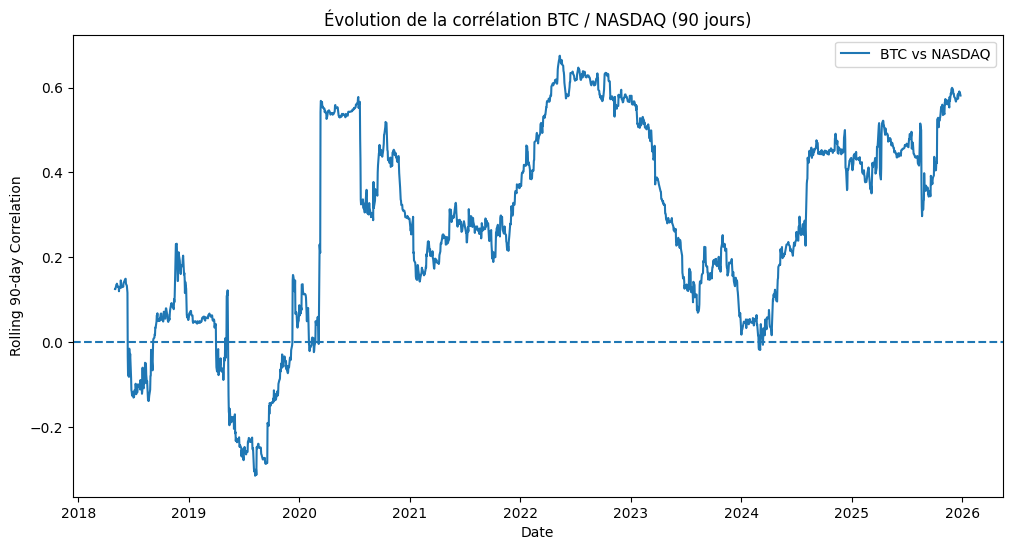

In [ ]:
plot_btc_nasdaq(df_final)

Le graphique met en évidence une corrélation très instable dans le temps entre Bitcoin et les indices boursiers traditionnels (Nasdaq et S&P 500). Contrairement aux actifs financiers classiques, dont la corrélation reste généralement plus stable, Bitcoin présente une structure de dépendance très volatile : certaines périodes montrent une corrélation nettement positive, tandis que d’autres phases se caractérisent par une décorrélation quasi totale.
Cette dynamique confirme que Bitcoin ne réagit pas systématiquement aux mêmes facteurs macroéconomiques que les actions. Les phases de corrélation élevée semblent principalement associées à des épisodes de tension macro ou financière, où les actifs risqués évoluent de manière plus synchronisée. À l’inverse, lorsque les conditions se normalisent, Bitcoin retrouve un comportement plus autonome.
Ces résultats suggèrent que Bitcoin ne pourrait pas être considéré comme un actif structurellement aligné avec les marchés actions : son potentiel de diversification dépend fortement de la période étudiée.

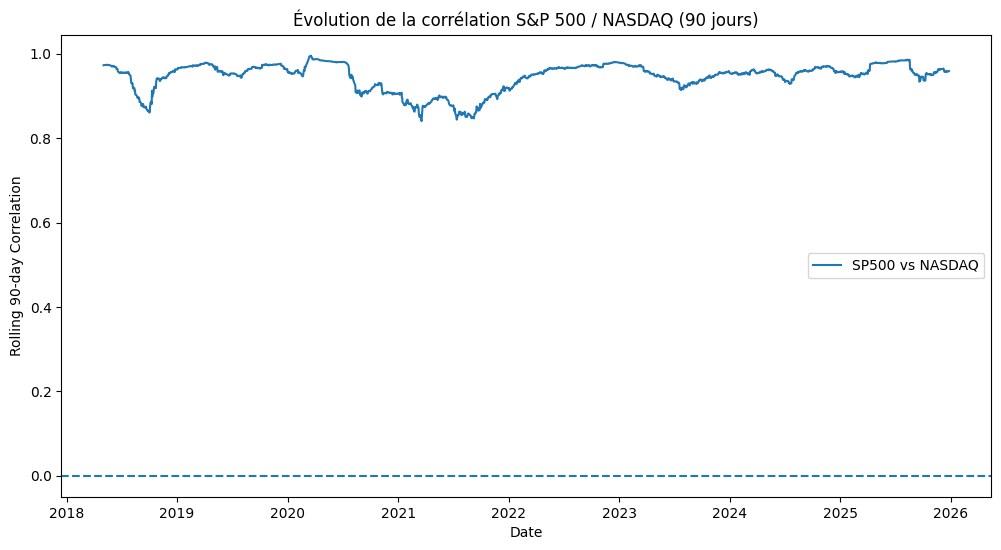

In [ ]:
plot_sp500_nasdaq(df_final)

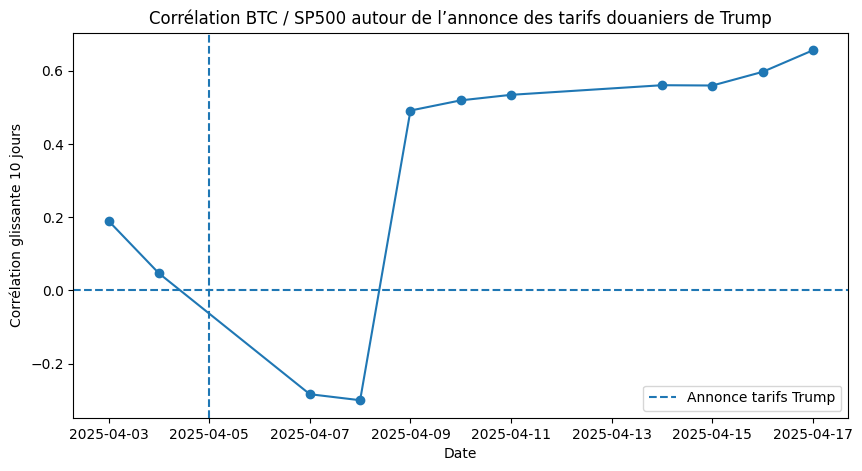

In [ ]:
plot_event_window(
    df_final,
    EVENT_DATE,
    window_days=EVENT_WINDOW_DAYS,
    rolling_days=EVENT_ROLLING_DAYS
)

Pendant l’annonce des tarifs douaniers, la corrélation BTC / SP500 augmente, car un choc macroéconomique majeur fait réagir simultanément les investisseurs sur plusieurs actifs. Cette corrélation élevée est temporaire, et Bitcoin reprend ensuite son comportement relativement indépendant comme on a pu le voir avec les graphes précédents.

## III/ Corrélation entre le Bitcoin, le NASDAQ et les taux d'intérêts américains

Cette section analyse la relation entre le Bitcoin et les taux d’intérêt américains à travers le taux des obligations du Trésor à 10 ans (US10Y). L’objectif est d’évaluer dans quelle mesure le Bitcoin est sensible aux conditions macroéconomiques, et en particulier au coût du capital.

### 1) BTC vs US10Y (prix/niveau du taux)

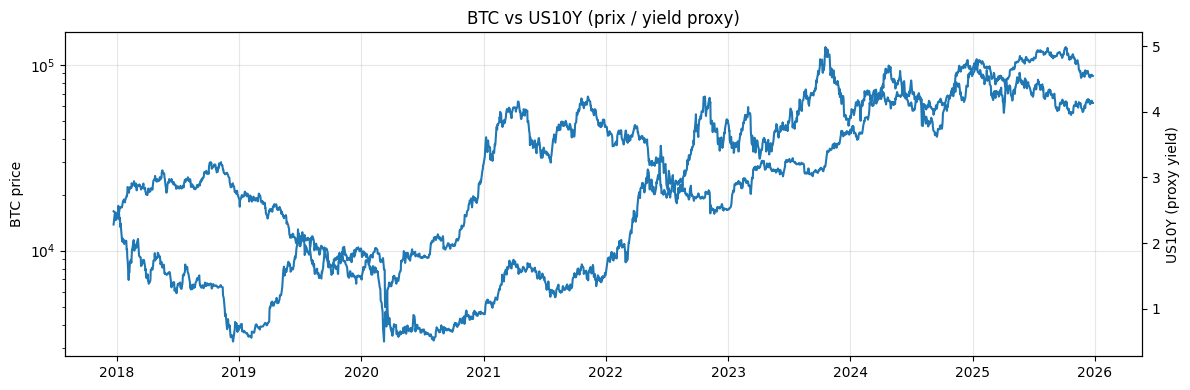

In [ ]:
plot_btc_and_us10y(df_final)

La comparaison entre le prix du Bitcoin (en échelle logarithmique) et le niveau du taux US10Y montre qu’il n’existe pas de relation évidente en niveau entre les deux séries.  
Le Bitcoin évolue selon des cycles marqués, tandis que le taux US10Y suit des dynamiques plus lentes, liées aux anticipations de politique monétaire et d’inflation.

Cette absence de relation en niveau justifie l’analyse des variations de court terme du taux (ΔUS10Y) et des rendements du Bitcoin plutôt que des niveaux de prix.

### 2) Corrélation glissante (60 jours) : BTC returns vs ΔUS10Y

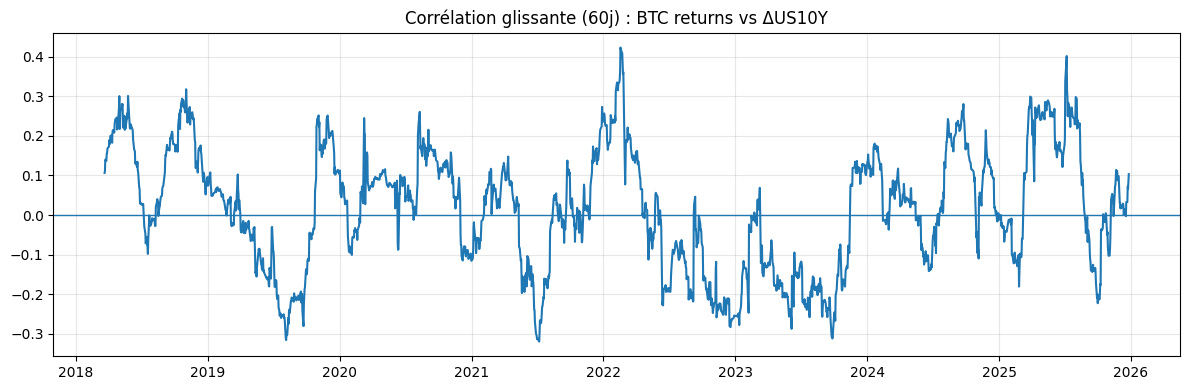

In [ ]:
plot_rolling_corr(df_final)

La corrélation glissante sur 60 jours entre les rendements du Bitcoin et les variations quotidiennes du taux US10Y est instable dans le temps.  
Elle alterne entre des phases positives et négatives, avec une valeur moyenne proche de zéro.

Ces résultats suggèrent que la relation entre Bitcoin et taux d’intérêt n’est pas structurelle mais dépend fortement du régime macroéconomique et financier. Le lien entre les deux variables peut se renforcer ou s’inverser selon les périodes.

### 3) Scatter : BTC returns vs ΔUS10Y (par régime de volatilité BTC)

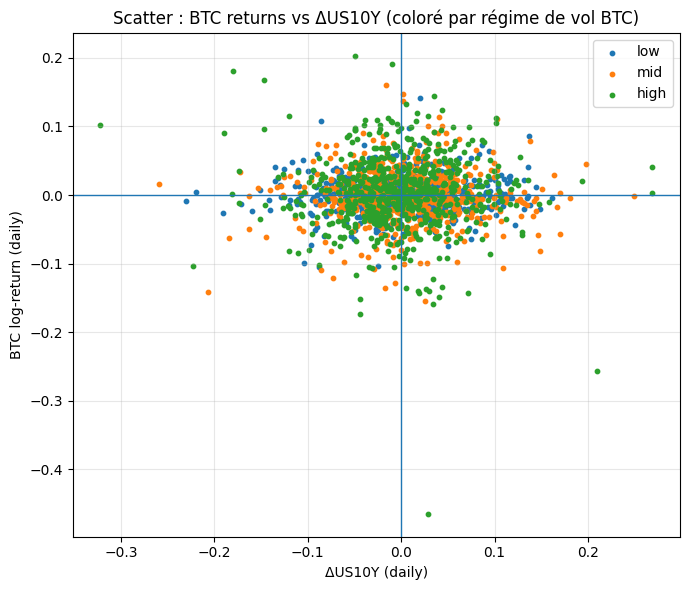

In [ ]:
plot_scatter_returns(df_final)

Le nuage de points représentant les rendements du Bitcoin en fonction de ΔUS10Y met en évidence une relation globale faible entre les deux variables.  
Cependant, lorsque la volatilité du Bitcoin est élevée, la dispersion des rendements est nettement plus importante.

Cela indique que les variations de taux n’expliquent pas directement les rendements du Bitcoin, mais qu’elles peuvent amplifier les mouvements du marché lors des périodes de forte instabilité.

### 4) Event study : BTC autour des chocs de taux (|ΔUS10Y| ≥ 99ᵉ percentile)

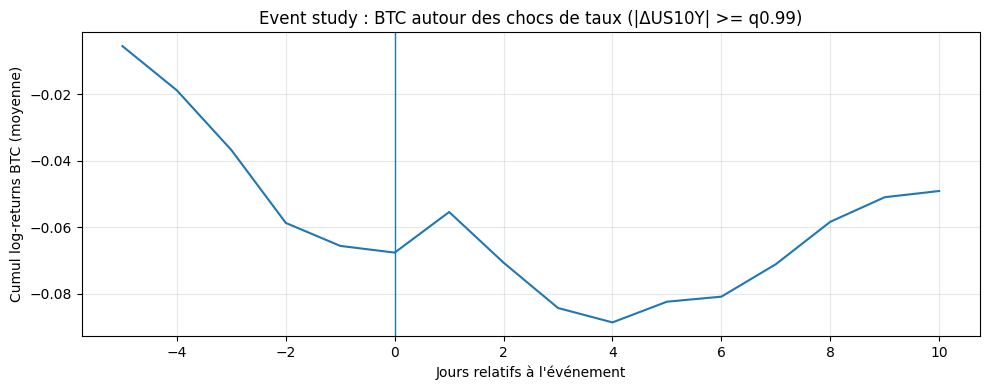

In [ ]:
plot_event_study_rate_shocks(df_final, shock_quantile=0.99, pre=5, post=10)

L’event study se concentre sur les jours où les variations du taux US10Y sont extrêmes (au-delà du 99ᵉ percentile).  
On observe que ces chocs de taux sont associés à des rendements cumulés négatifs du Bitcoin dans les jours qui suivent l’événement.

L’impact n’est pas strictement instantané, mais semble persister sur plusieurs jours, suggérant que les chocs de taux constituent des événements macroéconomiques défavorables pour le Bitcoin.


### 5) US10Y vs NASDAQ/S&P500

In [ ]:
plot_asset_and_us10y(
    df_final,
    asset_price_col="NASDAQ_price",
    asset_label="NASDAQ",
    log_asset=True,
    title="NASDAQ (log) vs US10Y"
)

plot_asset_and_us10y(
    df_final,
    asset_price_col="SP500_price",
    asset_label="S&P 500",
    log_asset=True,
    title="S&P 500 (log) vs US10Y"
)

### 6) Corrélations glissantes : actions vs ΔUS10Y

In [ ]:
plot_rolling_corr_generic(
    df_final,
    x_col="NASDAQ_return_daily",
    y_col="US10Y_return_daily",
    window=60,
    title="Rolling corr (60j): NASDAQ returns vs ΔUS10Y"
)

plot_rolling_corr_generic(
    df_final,
    x_col="SP500_return_daily",
    y_col="US10Y_return_daily",
    window=60,
    title="Rolling corr (60j): S&P 500 returns vs ΔUS10Y"
)

### 7) Event study multi-séries (BTC vs NASDAQ) sur les mêmes chocs de taux

In [ ]:
plot_event_study_rate_shocks_multi(
    df_final,
    shock_col="US10Y_return_daily",
    series_cols=["BTC_return_daily", "NASDAQ_return_daily"],
    shock_quantile=0.99,
    pre=5,
    post=10,
    title="BTC vs NASDAQ autour des chocs extrêmes de ΔUS10Y"
)

## Conclusion

Dans l’ensemble, l’analyse met en évidence une relation complexe et non linéaire entre le Bitcoin et les taux d’intérêt américains.  
Si aucune corrélation stable n’apparaît en moyenne, les variations de taux jouent un rôle important en période de stress macroéconomique et de forte volatilité du Bitcoin.

Ces résultats suggèrent que le Bitcoin se comporte davantage comme un actif risqué sensible aux conditions financières globales que comme un actif décorrélé des marchés traditionnels.